# Initializing

In [1]:
# Standard library
from typing import Iterable, Optional, Union, Tuple, Dict

# Data handling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn: preprocessing, models, metrics, and utils
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, make_scorer, precision_score, recall_score, f1_score
from sklearn.utils.validation import check_is_fitted

# Imbalanced-learn: pipelines and samplers
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.base import BaseSampler

from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from typing import Iterable, Optional, Union, Tuple

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.utils.validation import check_is_fitted

from imblearn.base import BaseSampler



# 

In [2]:
historical_df = pd.read_csv("../data/historical.csv")
historical_df['apgar_score'] = historical_df['apgar_score'].ffill()
historical_df.head()

# Set up the data and the target 
X = historical_df.iloc[:, :-1]
y = historical_df.iloc[:, -1]

We will set the simplest baseline model ever, which is literally just a logistic regression with all numerical variables that do not have a null value. Surprisingly, its test accuracy is 93%, which is similar to Data Monitor's model accuracy of 90.71%.

In [3]:
# Keep only numerical columns
num_cols = X.select_dtypes(include='number').columns.tolist()
num_cols.remove('apgar_score')

X_num = X[num_cols]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=42, stratify=y
)

logreg_pipeline = Pipeline([
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit the model
logreg_pipeline.fit(X_train, y_train)

# Predict
y_pred = logreg_pipeline.predict(X_test)

# Classification report
print("Train-Test Classification Report (Logistic Regression):\n")
print(classification_report(y_test, y_pred))



Train-Test Classification Report (Logistic Regression):

              precision    recall  f1-score   support

     At Risk       0.88      0.52      0.65        56
     Healthy       0.93      0.99      0.96       364

    accuracy                           0.93       420
   macro avg       0.90      0.75      0.81       420
weighted avg       0.92      0.93      0.92       420



The following columns were removed because they are already being measured by another similar variable.
* ```birth_weight_kg```
* ```birth_length_cm```
* ```birth_head_circumference_cm```

The following were removed because only serve as personally identifiable information.
* ```baby_id```
* ```name```

The following were removed because it is only relevant at birth.
* ```apgar_score```

Time series data is hard, guys. Let's not do that yet, so we drop the following
* ```date```

### Numerical Variables

Based on the histograms below, the following were **standardized** because visually, it makes sense to talk about the mean since the distribution is unimodal:

* `gestational_age_weeks`
* `weight_kg`
* `length_cm`
* `head_circumference_cm`
* `temperature_c`
* `heart_rate_bpm`
* `respiratory_rate_bpm`
* `oxygen_saturation`
* `jaundice_level_mg_dl`

The other numerical variables were **Min-Max scaled** because they have a relatively uniform distribution:

* `age_days`
* `feeding_frequency_per_day`
* `urine_output_count`
* `stool_count`

### Categorical Variables

All categorical variables were **one-hot encoded**. Namely:

* `gender`
* `feeding_type`
* `immunizations_done`
* `reflexes_normal`


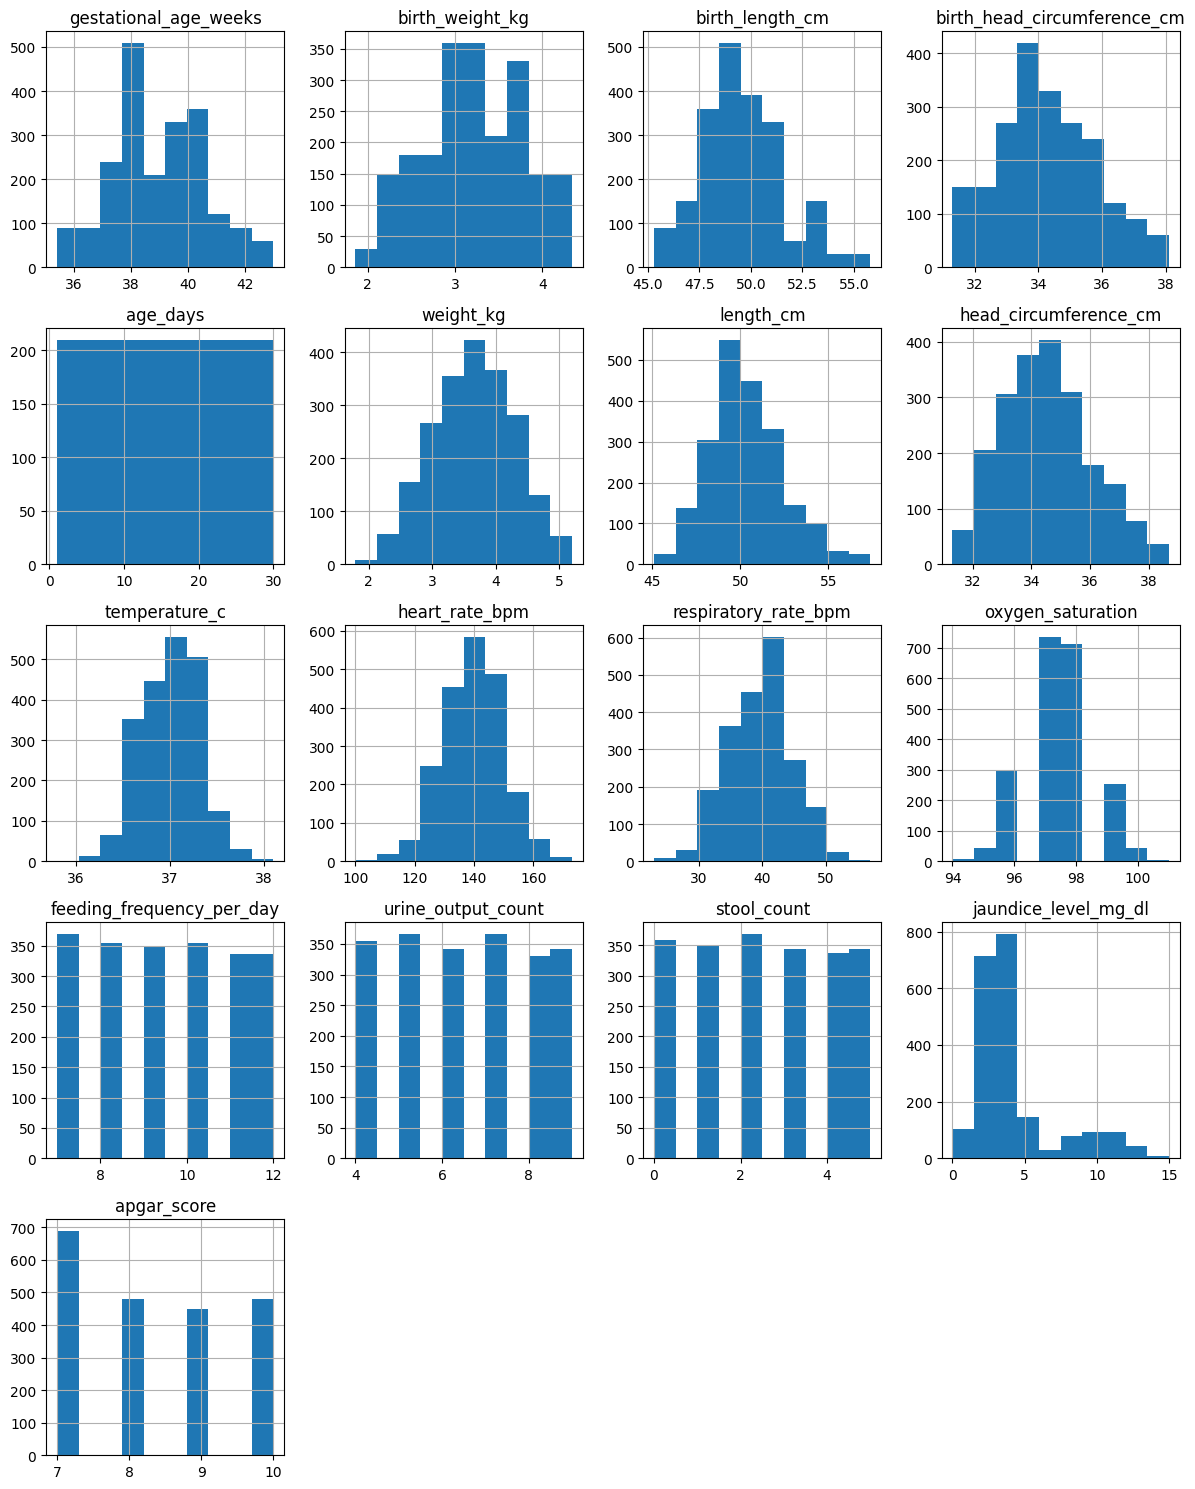

In [4]:
historical_df.hist(figsize=(12, 15))
plt.tight_layout()

In [5]:
# Columns for preprocessing
minmax_cols = ['age_days', 'feeding_frequency_per_day', 'urine_output_count', 'stool_count']
standardize_cols = [
    'gestational_age_weeks', 'weight_kg', 'length_cm', 'head_circumference_cm',
    'temperature_c', 'heart_rate_bpm', 'respiratory_rate_bpm', 'oxygen_saturation',
    'jaundice_level_mg_dl'
]
categorical_cols = ['gender', 'feeding_type', 'immunizations_done', 'reflexes_normal']


# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('minmax', MinMaxScaler(), minmax_cols),
        ('standard', StandardScaler(), standardize_cols),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='drop'  # all other columns (unlisted) are automatically dropped
)

In [6]:
class WhiteBox(BaseEstimator, ClassifierMixin):
    """
    A custom fraud detection model built on top of a Random Forest classifier.

    This class provides an extensible framework for experimenting with
    imbalanced classification problems, particularly in fraud detection.
    It integrates with scikit-learn and imbalanced-learn, allowing
    seamless use of pipelines, cross-validation, and custom scorers.

    Key Features
    ------------
    - Uses a Random Forest classifier with 500 estimators as a baseline.
    - Supports rebalancing strategies (e.g., SMOTE, undersampling,
      hybrid methods) via `experiment_fit`.
    - Provides custom scoring metrics tailored for fraud detection:
      * Absolute Net Value Gained (total amount of fraud correctly flagged).
      * Relative Net Value Gained (proportion of fraudulent value caught).
    - Compatible with scikit-learn model selection tools such as
      `GridSearchCV` and `Pipeline`.

    Parameters
    ----------
    random_state : int, default=39
        Random seed for reproducibility of the Random Forest model.
    n_jobs : int, optional
        Number of CPU cores to use for training the Random Forest.
        If None, scikit-learn defaults are used.

    Attributes
    ----------
    _model_ : RandomForestClassifier
        The underlying Random Forest classifier.
    """
    
    def __init__(self, preprocessor=preprocessor, random_state: int = 39, n_jobs: Optional[int] = None):
        self.random_state = random_state
        self.n_jobs = n_jobs
        self._model_ = RandomForestClassifier(
            n_estimators=500,
            n_jobs=self.n_jobs,
            random_state=self.random_state,
        )
        self.preprocessor = preprocessor
        steps = []
        steps.append(("preprocess", self.preprocessor))
        steps.append(("clf", self._model_)) 
        self.pipeline = ImbPipeline(steps=steps)


    def fit(
        self,
        X: Union[np.ndarray, pd.DataFrame],
        y: Union[np.ndarray, pd.Series],
    ):
        """
        Fit the model using a training X and y.

        Parameters:
        -----------
        X (np.ndarray | pd.DataFrame): The training data
        y (np.ndarray | pd.Sereis): The corresponding targets
        sample_weight (iterable): Sample class weights (default=None)
        """

        self._model_.fit(X, y)
        return self

    def predict(self, X: Union[np.ndarray, pd.DataFrame]) -> np.ndarray:
        """Predict the outcome from data X."""
        check_is_fitted(self, "_model_")
        return self._model_.predict(X)

    def fit_predict(
        self, X: Union[np.ndarray, pd.DataFrame], y: Union[np.ndarray, pd.Series]
    ) -> np.ndarray:
        """
        Fit the model using a training X and y, and predict the outcome using
        X. Note that this would give the predicted labels during training.
        """
        return self.fit(X, y).predict(X)
    
    def cross_validate_pipeline(
        self,
        X,
        y,
        test_model,
        sample_strategy: Optional[BaseSampler] = None,
        n_splits: int = 5,
        random_state: int = 42,
        n_jobs: int = 1,
    ) -> Dict[str, any]:
        # Define scorers
        scorers = {
            "precision": make_scorer(precision_score, zero_division=0, average="binary", pos_label="At Risk"),
            "recall": make_scorer(recall_score, zero_division=0, average="binary", pos_label="At Risk"),
            "recall_at_risk": make_scorer(recall_score, zero_division=0, pos_label="At Risk"),
            "recall_healthy": make_scorer(recall_score, zero_division=0, pos_label="Healthy"),
            "f1": make_scorer(f1_score, zero_division=0, average="binary", pos_label="At Risk"),
        }

        # Stratified K-Fold
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

        # Build pipeline
        steps = []
        if self.preprocessor is not None:
            steps.append(("preprocess", self.preprocessor))
        if sample_strategy is not None:
            steps.append(("sampler", sample_strategy))
        steps.append(("clf", test_model))

        pipeline = ImbPipeline(steps=steps)

        # Fit pipeline (optional, not strictly needed for cross_validate)
        pipeline.fit(X, y)

        # Run cross-validation
        cv_results = cross_validate(
            estimator=pipeline,
            X=X,
            y=y,
            cv=skf,
            scoring=scorers,
            n_jobs=n_jobs,
            return_train_score=True
        )

        return cv_results


In [7]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Base model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Initialize WhiteBox
fd = WhiteBox()

# Define sampling strategies
sampling_strategies = {
    "RF Nothing": None,
    "RF SMOTE": SMOTE(random_state=42),
    "RF ADASYN": ADASYN(random_state=42),
    "RF RandomOverSampler": RandomOverSampler(random_state=42),
    "RF RandomUnderSampler": RandomUnderSampler(random_state=42)
}

# Store results
cv_results_summary = {}

for name, sampler in sampling_strategies.items():
    print(f"Running cross-validation with {name}...")
    cv_results = fd.cross_validate_pipeline(
        X=X_train,
        y=y_train,
        test_model=rf_model,
        sample_strategy=sampler
    )
    # Convert to DataFrame and take mean of train/test scores
    cv_results_summary[name] = pd.DataFrame(cv_results).mean()

# Combine results into a single DataFrame
cv_results_summary_df = pd.DataFrame(cv_results_summary).T

rel_cols = ['test_precision', 'test_recall', 'test_recall_at_risk', 'test_f1']
cv_results_summary_df[rel_cols]

Running cross-validation with RF Nothing...
Running cross-validation with RF SMOTE...
Running cross-validation with RF ADASYN...
Running cross-validation with RF RandomOverSampler...
Running cross-validation with RF RandomUnderSampler...


,test_precision,test_recall,test_recall_at_risk,test_f1
RF Nothing,1.000000,0.991111,0.991111,0.995455
RF SMOTE,0.986957,0.982121,0.982121,0.984465
RF ADASYN,0.974444,0.991111,0.991111,0.982415
RF RandomOverSampler,0.991111,0.991111,0.991111,0.991111
RF RandomUnderSampler,0.905583,0.991111,0.991111,0.944621


In [11]:
from sklearn.ensemble import GradientBoostingClassifier

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Base model: Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Initialize WhiteBox
fd = WhiteBox()

# Define sampling strategies
sampling_strategies = {
    "GB Nothing": None,
    "GB SMOTE": SMOTE(random_state=42),
    "GB ADASYN": ADASYN(random_state=42),
    "GB RandomOverSampler": RandomOverSampler(random_state=42),
    "GB RandomUnderSampler": RandomUnderSampler(random_state=42)
}

# Store results
cv_results_summary = {}

for name, sampler in sampling_strategies.items():
    print(f"Running cross-validation with {name}...")
    cv_results = fd.cross_validate_pipeline(
        X=X_train,
        y=y_train,
        test_model=gb_model,        # Use Gradient Boosting model here
        sample_strategy=sampler
    )
    # Convert to DataFrame and take mean of train/test scores
    cv_results_summary[name] = pd.DataFrame(cv_results).mean()

# Combine results into a single DataFrame
cv_results_summary_df = pd.DataFrame(cv_results_summary).T

# Show relevant metrics
rel_cols = ['test_precision', 'test_recall', 'test_recall_at_risk', 'test_f1']
cv_results_summary_df[rel_cols]


Running cross-validation with GB Nothing...
Running cross-validation with GB SMOTE...
Running cross-validation with GB ADASYN...
Running cross-validation with GB RandomOverSampler...
Running cross-validation with GB RandomUnderSampler...


,test_precision,test_recall,test_recall_at_risk,test_f1
GB Nothing,1.000000,0.991111,0.991111,0.995455
GB SMOTE,0.995556,0.991111,0.991111,0.993207
GB ADASYN,0.991304,0.991111,0.991111,0.991010
GB RandomOverSampler,1.000000,0.991111,0.991111,0.995455
GB RandomUnderSampler,1.000000,0.991111,0.991111,0.995455


Random Forest model trained successfully.

Model Performance on Test Set:
              precision    recall  f1-score   support

     At Risk       1.00      0.98      0.99        56
     Healthy       1.00      1.00      1.00       364

    accuracy                           1.00       420
   macro avg       1.00      0.99      0.99       420
weighted avg       1.00      1.00      1.00       420


Calculating permutation importance with 30 repeats (this may take a while)...

Feature importance (Permutation Importance):


,Feature,Importance,Std
8,jaundice_level_mg_dl,0.581548,0.029045
7,oxygen_saturation,0.173214,0.010463
5,heart_rate_bpm,0.122619,0.006070
10,feeding_frequency_per_day,0.000000,0.000000
15,immunizations_done,0.000000,0.000000
14,feeding_type,0.000000,0.000000
13,gender,0.000000,0.000000
12,stool_count,0.000000,0.000000
11,urine_output_count,0.000000,0.000000
0,gestational_age_weeks,0.000000,0.000000



Figure saved as: permutation_importance_plot_20251017_200041.png


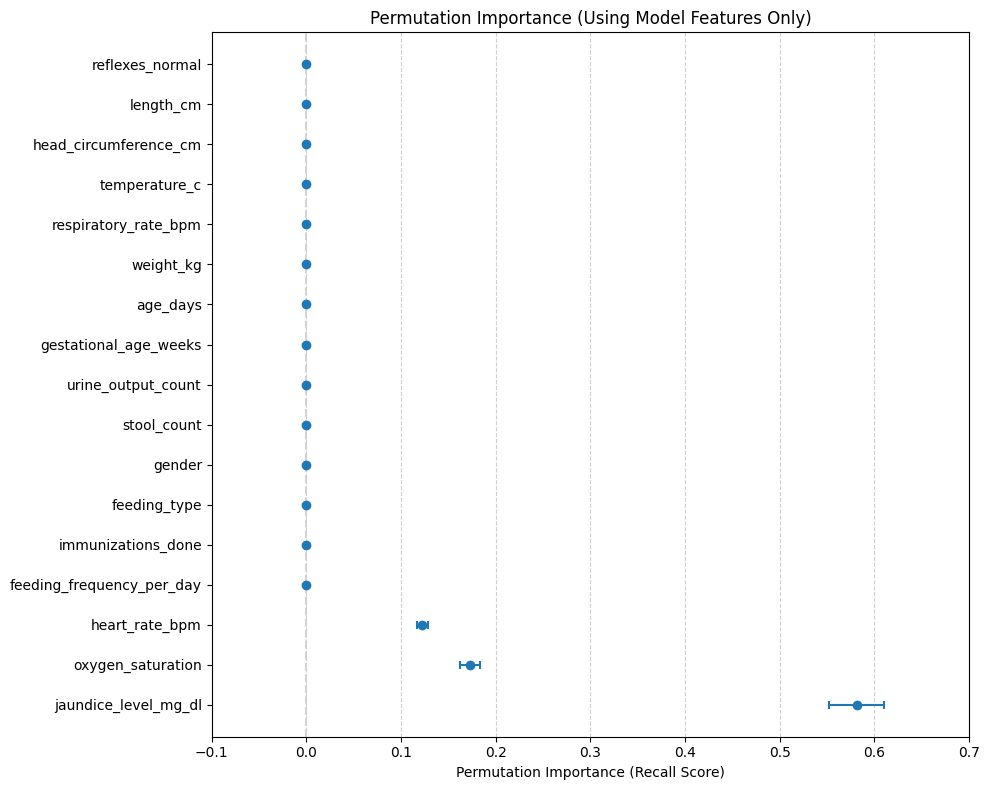

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, recall_score, make_scorer
from sklearn.inspection import permutation_importance
from datetime import datetime

# Define features
numerical_standard = ['gestational_age_weeks', 'weight_kg', 'length_cm', 'head_circumference_cm', 
                      'temperature_c', 'heart_rate_bpm', 'respiratory_rate_bpm', 'oxygen_saturation', 
                      'jaundice_level_mg_dl']
numerical_minmax = ['age_days', 'feeding_frequency_per_day', 'urine_output_count', 'stool_count']
categorical = ['gender', 'feeding_type', 'immunizations_done', 'reflexes_normal']
selected_cols = numerical_standard + numerical_minmax + categorical

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num_standard', StandardScaler(), numerical_standard),
        ('num_minmax', MinMaxScaler(), numerical_minmax),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical)
    ])

# Create the Random Forest model with the specified parameters
rf_model = RandomForestClassifier(n_estimators=500, random_state=42)

# Create the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

# Select data and split for training and testing
X_selected = X[selected_cols]
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

# Train the model
pipeline.fit(X_train, y_train)
print("Random Forest model trained successfully.")

# Evaluate the model
y_pred = pipeline.predict(X_test)
print("\nModel Performance on Test Set:")
print(classification_report(y_test, y_pred))

# Number of repeats for permutation importance
n_repeats = 30  # You can adjust this number as needed

# Create a custom scoring function that specifies 'At Risk' as the positive label
recall_scorer = make_scorer(recall_score, pos_label='At Risk')

# Calculate permutation importance with the custom scorer
print(f"\nCalculating permutation importance with {n_repeats} repeats (this may take a while)...")
perm_importance = permutation_importance(
    pipeline, X_test, y_test, 
    n_repeats=n_repeats,
    random_state=42,
    scoring=recall_scorer  # Using the custom recall scorer
)

# Create a DataFrame with permutation importance results using the original feature names
importance_df = pd.DataFrame({
    'Feature': selected_cols,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

# Display the feature importance results
print("\nFeature importance (Permutation Importance):")
display(importance_df)

# Create the plot matching the provided example style
plt.figure(figsize=(10, 8))

# Get all features for plotting
ordered_labels = importance_df['Feature'].values
ordered_means = importance_df['Importance'].values
ordered_stds = importance_df['Std'].values

# Create the exact style from the image
plt.errorbar(
    x=ordered_means,
    y=range(len(ordered_labels)),
    xerr=ordered_stds,
    fmt='o',
    capsize=3,
    color='#1f77b4',  # Match the blue color in the image
    elinewidth=1.5,
    capthick=1.5
)

# Set y-tick positions and labels (reversed to match the image order)
plt.yticks(range(len(ordered_labels)), ordered_labels)

# Add grid and styling to match the image
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.xlabel("Permutation Importance (Recall Score)")
plt.title("Permutation Importance (Using Model Features Only)")

# Add a vertical line at x=0 as in the image
plt.axvline(0, linestyle="--", c="lightgray")

# Set x-axis limits similar to the image
plt.xlim(-0.1, 0.7)

# Adjust layout
plt.tight_layout()

# Generate timestamp for unique filename
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save the figure directly without a path
plt.savefig(f"permutation_importance_plot_{timestamp}.png", dpi=300, bbox_inches='tight')
print(f"\nFigure saved as: permutation_importance_plot_{timestamp}.png")

# Display the figure
plt.show()


In [ ]:
# Compute permutation importance on the pipeline
perm_imp = permutation_importance(
    old_model,
    X,
    y,
    scoring="recall",
    random_state=42,
    n_repeats=5
)

# Use raw column names (not preprocessed ones) for interpretability
FEATURE_NAMES = np.array(X.columns)

# Sort by importance
idx_order = np.argsort(-perm_imp.importances_mean)
ordered_means = perm_imp.importances_mean[idx_order]
ordered_stds = perm_imp.importances_std[idx_order]
ordered_labels = FEATURE_NAMES[idx_order]

# Plot
plt.figure(figsize=(10, 5))
plt.errorbar(
    x=ordered_means,
    y=ordered_labels,
    xerr=ordered_stds,
    fmt="o",
    capsize=3
)
plt.xlabel("Permutation Importance (Recall Score)")
plt.axvline(0, linestyle="--", c="lightgray")
#plt.title("Permutation Importance (Using Model Features Only)")
plt.tight_layout()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

print(f'\033[1mFigure {fig_count}\033[0m. '
      'Permutation Importance'
)

fig_count += 1 
